# Análisis exploratorio de la demanda turística rural

Este notebook analiza la tabla `gold_tourism_demand_monthly.parquet`.

**Objetivos:**

- comprobar la estructura y cobertura del dataset;
- analizar la evolución temporal de viajeros y pernoctaciones;
- estudiar la estacionalidad;
- comparar provincias;
- revisar los indicadores de ocupación y presión turística;
- analizar el caso de Santa Cruz de Tenerife;
- dejar conclusiones reproducibles para las siguientes fases del TFM.

La unidad de análisis es una combinación de **provincia y mes**.

## 1. Configuración y carga de datos

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd()

# Permite ejecutar el notebook tanto desde la raíz como desde notebooks/.
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

GOLD_PATH = (
    PROJECT_ROOT
    / "data"
    / "gold"
    / "gold_tourism_demand_monthly.parquet"
)

if not GOLD_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset gold en: {GOLD_PATH}"
    )

df = pd.read_parquet(GOLD_PATH)
df["date_month"] = pd.to_datetime(df["date_month"])

print(
    "Dataset cargado:",
    GOLD_PATH.relative_to(PROJECT_ROOT).as_posix(),
)
print(f"Filas: {len(df):,}")
print(f"Columnas: {len(df.columns)}")

Dataset cargado: data/gold/gold_tourism_demand_monthly.parquet
Filas: 12,693
Columnas: 64


## 2. Comprobaciones iniciales

In [2]:
summary = pd.Series(
    {
        "filas": len(df),
        "columnas": len(df.columns),
        "territorios": df["territory_id"].nunique(),
        "primer_mes": df["date_month"].min(),
        "último_mes": df["date_month"].max(),
        "claves_duplicadas": df.duplicated(
            ["territory_id", "month_id"]
        ).sum(),
        "filas_provisionales": df["is_provisional"]
        .fillna(False)
        .sum(),
    }
)

summary

filas                                12693
columnas                                64
territorios                             50
primer_mes             2005-01-01 00:00:00
último_mes             2026-05-01 00:00:00
claves_duplicadas                        0
filas_provisionales                    600
dtype: object

In [3]:
df.head()

,territory_id,source_territory_code,source_territory_name,territory_name,territory_level,autonomous_community_id,autonomous_community_name,province_id,coverage_quality,month_id,date_month,year,month,month_name,quarter,season,is_summer,is_christmas_period,is_easter_period,covid_period,complete_month_available,travellers_total,travellers_domestic,travellers_foreign,overnight_stays_total,overnight_stays_domestic,overnight_stays_foreign,average_stay,establishments_estimated,places_estimated,occupancy_rate_pct,weekend_occupancy_rate_pct,room_occupancy_rate_pct,staff_employed,domestic_travellers_share,foreign_travellers_share,domestic_overnight_stays_share,foreign_overnight_stays_share,overnight_stays_per_place,travellers_per_establishment,weekend_dependence_index,overnight_stays_mom_change_pct,overnight_stays_yoy_change_pct,seasonality_index,tourism_pressure_index,price_index,price_yoy_change_pct,resident_avg_spend_context,foreign_avg_spend_context,demand_source_frequency,price_source_frequency,price_territory_level,spend_context_frequency,spend_context_territory_level,business_context_frequency,business_context_territory_level,data_status,is_provisional,demand_snapshot_id,supply_snapshot_id,source_snapshot_id,pipeline_run_id,data_version,created_at
0,ES-PROV-01,01,Araba/Álava,Araba/Álava,province,ES-CCAA-16,País Vasco,ES-PROV-01,high,2005-01,2005-01-01,2005,1,enero,1,winter,False,True,<NA>,False,True,620,598,22,1094,1019,75,1.76,54.00,498.00,7.06,16.53,<NA>,92.00,0.96,0.04,0.93,0.07,2.20,11.48,134.14,<NA>,<NA>,17.13,20.90,<NA>,<NA>,<NA>,<NA>,monthly,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,final_or_not_marked_provisional,False,39131dec216c6f81ceb679e3391aeaa8c19747a93691a9...,50f464cc3a19c00094a6df73b56a8b1cd0dc36e986e596...,bfebaf7a07072b8c9a2c000e41e19459e78b5d693f3c84...,4f1779a2-f7f3-4ffe-a1d4-9cfdcba4612e,gold_tourism_demand_monthly_v1.0.0,2026-07-14 10:16:48.890767+00:00
1,ES-PROV-01,01,Araba/Álava,Araba/Álava,province,ES-CCAA-16,País Vasco,ES-PROV-01,high,2005-02,2005-02-01,2005,2,febrero,1,winter,False,False,<NA>,False,True,856,820,36,1796,1600,196,2.10,54.00,506.00,12.63,22.18,<NA>,96.00,0.96,0.04,0.89,0.11,3.55,15.85,75.61,64.17,<NA>,21.86,35.87,<NA>,<NA>,<NA>,<NA>,monthly,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,final_or_not_marked_provisional,False,39131dec216c6f81ceb679e3391aeaa8c19747a93691a9...,50f464cc3a19c00094a6df73b56a8b1cd0dc36e986e596...,bfebaf7a07072b8c9a2c000e41e19459e78b5d693f3c84...,4f1779a2-f7f3-4ffe-a1d4-9cfdcba4612e,gold_tourism_demand_monthly_v1.0.0,2026-07-14 10:16:48.890767+00:00
2,ES-PROV-01,01,Araba/Álava,Araba/Álava,province,ES-CCAA-16,País Vasco,ES-PROV-01,high,2005-03,2005-03-01,2005,3,marzo,1,spring,False,False,<NA>,False,True,1523,1461,62,3839,3764,75,2.52,55.00,512.00,23.89,40.78,<NA>,96.00,0.96,0.04,0.98,0.02,7.50,27.69,70.70,113.75,<NA>,36.58,42.30,<NA>,<NA>,<NA>,<NA>,monthly,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,final_or_not_marked_provisional,False,39131dec216c6f81ceb679e3391aeaa8c19747a93691a9...,50f464cc3a19c00094a6df73b56a8b1cd0dc36e986e596...,bfebaf7a07072b8c9a2c000e41e19459e78b5d693f3c84...,4f1779a2-f7f3-4ffe-a1d4-9cfdcba4612e,gold_tourism_demand_monthly_v1.0.0,2026-07-14 10:16:48.890767+00:00
3,ES-PROV-01,01,Araba/Álava,Araba/Álava,province,ES-CCAA-16,País Vasco,ES-PROV-01,high,2005-04,2005-04-01,2005,4,abril,2,spring,False,False,<NA>,False,True,1320,1251,69,2168,2087,81,1.64,53.00,492.00,14.65,33.27,<NA>,93.00,0.95,0.05,0.96,0.04,4.41,24.91,127.10,-43.53,<NA>,51.56,34.92,<NA>,<NA>,<NA>,<NA>,monthly,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,final_or_not_marked_provisional,False,39131dec216c6f81ceb679e3391aeaa8c19747a93691a9...,50f464cc3a19c00094a6df73b56a8b1cd0dc36e986e596...,bfebaf7a07072b8c9a2c000e41e19459e78b5d693f3c84...,4f1779a2-f7f3-4ffe-a1d4-9cfdcba4612e,gold_tourism_demand_monthly_v1.0.0,2026-07-14 10:16:48.890767+00:00
4,ES-PROV-01,01,Araba/Álava,Araba/Álava,province,ES-CCAA-16,País Vasco,ES-PROV-01,high,2005-05,2005-05-01,2005,5,mayo,2,spring,False,False,<NA>,False,True,1527,1430,97,3029,2684,345,1.98,55.00,510.00

In [4]:
df.dtypes.to_frame("tipo")

,tipo
territory_id,str
source_territory_code,string
source_territory_name,string
territory_name,string
territory_level,str
...,...
supply_snapshot_id,str
source_snapshot_id,str
pipeline_run_id,str
data_version,str


### Interpretación esperada

El dataset debe contener 50 provincias, cero claves duplicadas y una cobertura temporal desde enero de 2005 hasta mayo de 2026. Los datos desde junio de 2025 están marcados como provisionales.

## 3. Valores nulos en variables principales

In [5]:
main_columns = [
    "travellers_total",
    "overnight_stays_total",
    "average_stay",
    "establishments_estimated",
    "places_estimated",
    "occupancy_rate_pct",
    "weekend_occupancy_rate_pct",
    "room_occupancy_rate_pct",
    "staff_employed",
    "overnight_stays_yoy_change_pct",
    "tourism_pressure_index",
]

missingness = (
    df[main_columns]
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(
        columns={
            "sum": "nulos",
            "mean": "proporción_nulos",
        }
    )
)

missingness["porcentaje_nulos"] = (
    missingness["proporción_nulos"] * 100
)

missingness[
    ["nulos", "porcentaje_nulos"]
].sort_values("porcentaje_nulos", ascending=False)

,nulos,porcentaje_nulos
room_occupancy_rate_pct,"1,193.00",9.40
overnight_stays_yoy_change_pct,766.00,6.03
average_stay,16.00,0.13
overnight_stays_total,0.00,0.00
travellers_total,0.00,0.00
establishments_estimated,0.00,0.00
places_estimated,0.00,0.00
weekend_occupancy_rate_pct,0.00,0.00
occupancy_rate_pct,0.00,0.00
staff_employed,0.00,0.00


Los nulos no se imputan en esta fase. Deben interpretarse como valores no publicados o no disponibles en la fuente original.

## 4. Estadísticos descriptivos

In [6]:
descriptive_columns = [
    "travellers_total",
    "overnight_stays_total",
    "average_stay",
    "establishments_estimated",
    "places_estimated",
    "occupancy_rate_pct",
    "weekend_occupancy_rate_pct",
    "room_occupancy_rate_pct",
    "staff_employed",
    "tourism_pressure_index",
]

df[descriptive_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
travellers_total,"12,693.00","5,595.16","6,292.19",0.00,"2,163.00","3,748.00","6,958.00","79,179.00"
overnight_stays_total,"12,693.00","15,589.08","23,005.17",0.00,"5,089.00","9,235.00","17,833.00","304,655.00"
average_stay,"12,677.00",2.68,1.25,1.11,2.02,2.34,2.89,54.83
establishments_estimated,"12,693.00",296.51,244.08,0.00,130.00,209.00,420.00,"1,679.00"
places_estimated,"12,693.00","2,792.02","2,133.16",0.00,"1,360.00","2,163.00","3,704.00","16,069.00"
occupancy_rate_pct,"12,693.00",17.01,11.20,0.00,9.82,14.29,20.59,86.39
weekend_occupancy_rate_pct,"12,693.00",29.33,12.70,0.00,20.38,28.12,37.10,90.46
room_occupancy_rate_pct,"11,500.00",20.77,13.12,0.25,12.11,17.44,25.09,87.60
staff_employed,"12,693.00",445.42,387.46,0.00,203.00,313.00,609.00,"4,331.00"
tourism_pressure_index,"12,693.00",34.98,15.12,0.00,23.85,35.04,45.83,92.00


## 5. Evolución mensual agregada de España

La suma provincial permite observar la evolución general de la demanda turística rural. No debe mezclarse con agregados autonómicos o nacionales procedentes de otras tablas.

In [7]:
national_monthly = (
    df.groupby("date_month", as_index=False)
    .agg(
        travellers_total=("travellers_total", "sum"),
        overnight_stays_total=("overnight_stays_total", "sum"),
    )
    .sort_values("date_month")
)

national_monthly.tail()

,date_month,travellers_total,overnight_stays_total
249,2026-01-01,188738,463195
250,2026-02-01,219277,506364
251,2026-03-01,288999,678092
252,2026-04-01,431915,1070017
253,2026-05-01,481671,1110269


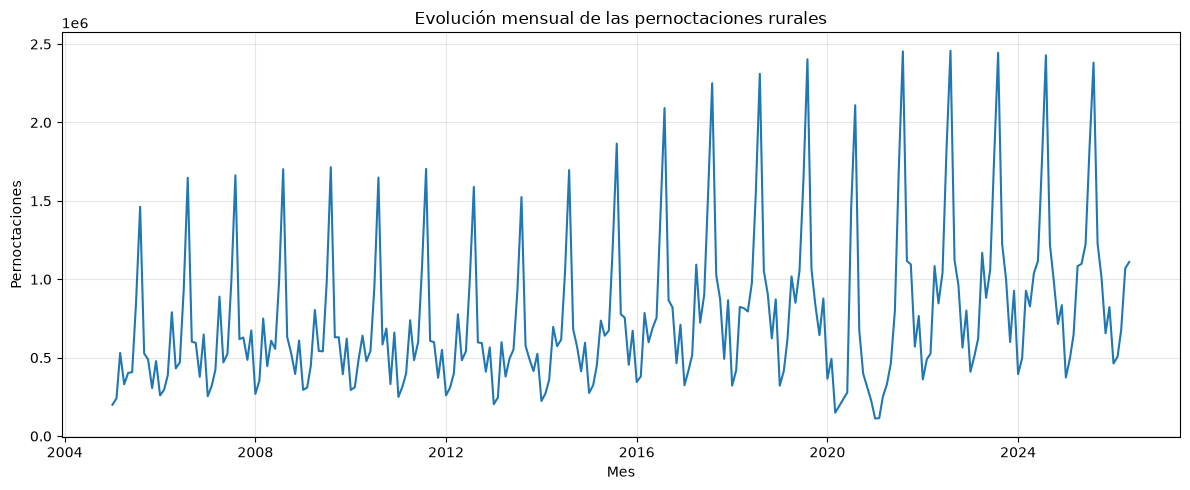

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(national_monthly["date_month"], national_monthly["overnight_stays_total"])
ax.set_title("Evolución mensual de las pernoctaciones rurales")
ax.set_xlabel("Mes")
ax.set_ylabel("Pernoctaciones")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

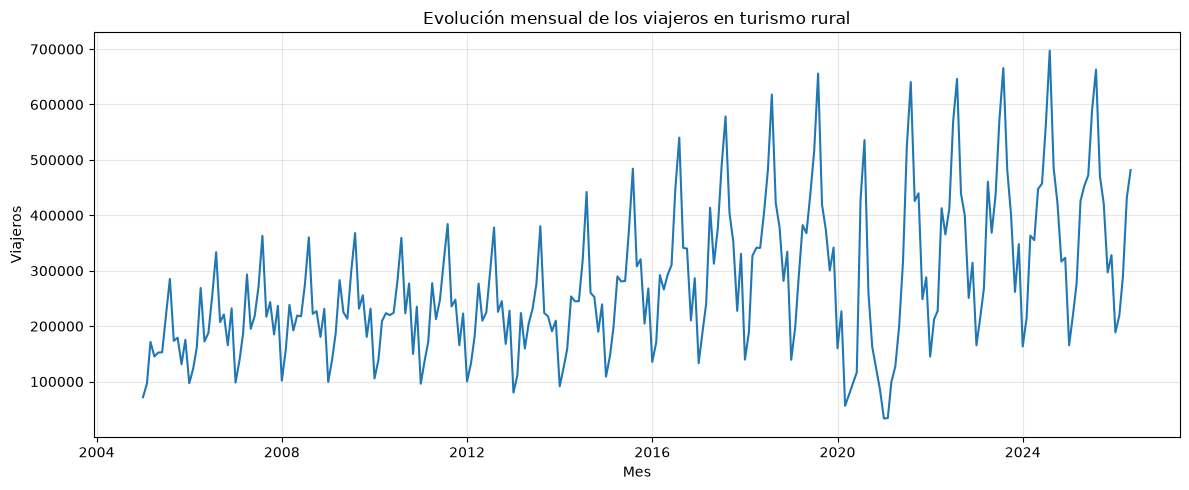

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(national_monthly["date_month"], national_monthly["travellers_total"])
ax.set_title("Evolución mensual de los viajeros en turismo rural")
ax.set_xlabel("Mes")
ax.set_ylabel("Viajeros")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparación anual

Para evitar comparar un año incompleto con años completos, se muestran por separado los años cerrados y el año 2026.

In [10]:
annual_summary = (
    df.groupby("year", as_index=False)
    .agg(
        travellers_total=("travellers_total", "sum"),
        overnight_stays_total=("overnight_stays_total", "sum"),
        months_available=("month_id", "nunique"),
        contains_provisional_data=("is_provisional", "max"),
    )
    .sort_values("year")
)

annual_summary.tail(10)

,year,travellers_total,overnight_stays_total,months_available,contains_provisional_data
12,2017,4049979,11033765,12,False
13,2018,4260669,11457727,12,False
14,2019,4421390,11726041,12,False
15,2020,2032968,6146783,9,False
16,2021,3379873,9779188,12,False
17,2022,4395547,12070363,12,False
18,2023,4647839,12613494,12,False
19,2024,4808447,12720136,12,False
20,2025,4785928,12851831,12,True
21,2026,1610600,3827937,5,True


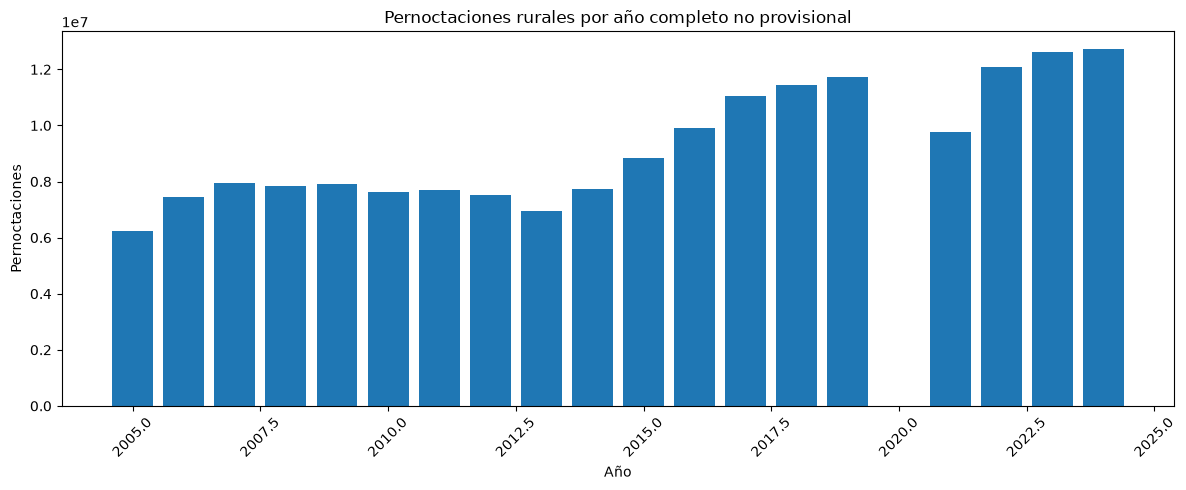

In [11]:
complete_years = annual_summary[
    (annual_summary["months_available"] == 12)
    & ~annual_summary["contains_provisional_data"].fillna(False)
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(complete_years["year"], complete_years["overnight_stays_total"])
ax.set_title("Pernoctaciones rurales por año completo no provisional")
ax.set_xlabel("Año")
ax.set_ylabel("Pernoctaciones")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Efecto del periodo COVID-19

In [12]:
covid_comparison = (
    df.assign(
        period_group=df["covid_period"].map(
            {True: "periodo_covid", False: "fuera_periodo_covid"}
        )
    )
    .groupby("period_group", as_index=False)
    .agg(
        monthly_mean_travellers=("travellers_total", "mean"),
        monthly_mean_overnight_stays=("overnight_stays_total", "mean"),
        observations=("territory_id", "size"),
    )
)

covid_comparison

,period_group,monthly_mean_travellers,monthly_mean_overnight_stays,observations
0,fuera_periodo_covid,"5,619.81","15,567.15",11743
1,periodo_covid,"5,290.36","15,860.11",950


Los meses abril de 2020, mayo de 2020 y noviembre de 2020 no aparecen en la tabla gold porque no contienen métricas provinciales de demanda publicadas. No deben interpretarse como demanda igual a cero.

## 8. Estacionalidad mensual

In [13]:
seasonal_monthly = (
    df[
        ~df["covid_period"].fillna(False)
        & ~df["is_provisional"].fillna(False)
    ]
    .groupby(["month", "month_name"], as_index=False)
    .agg(
        mean_overnight_stays=("overnight_stays_total", "mean"),
        mean_occupancy_rate=("occupancy_rate_pct", "mean"),
        mean_pressure_index=("tourism_pressure_index", "mean"),
    )
    .sort_values("month")
)

seasonal_monthly

,month,month_name,mean_overnight_stays,mean_occupancy_rate,mean_pressure_index
0,1,enero,"6,008.43",8.51,30.22
1,2,febrero,"7,424.39",10.92,31.95
2,3,marzo,"11,261.06",13.91,33.61
3,4,abril,"15,718.46",18.00,35.71
4,5,mayo,"13,203.39",14.08,33.64
5,6,junio,"14,372.43",15.20,34.24
6,7,julio,"24,949.52",24.16,38.55
7,8,agosto,"38,447.66",37.82,45.06
8,9,septiembre,"16,010.87",16.91,34.96
9,10,octubre,"14,392.11",16.17,35.00


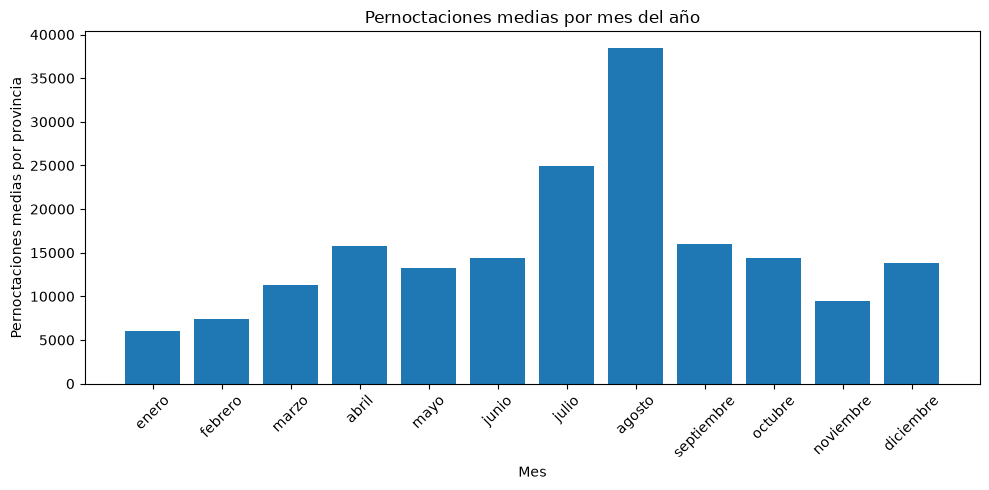

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(seasonal_monthly["month_name"], seasonal_monthly["mean_overnight_stays"])
ax.set_title("Pernoctaciones medias por mes del año")
ax.set_xlabel("Mes")
ax.set_ylabel("Pernoctaciones medias por provincia")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

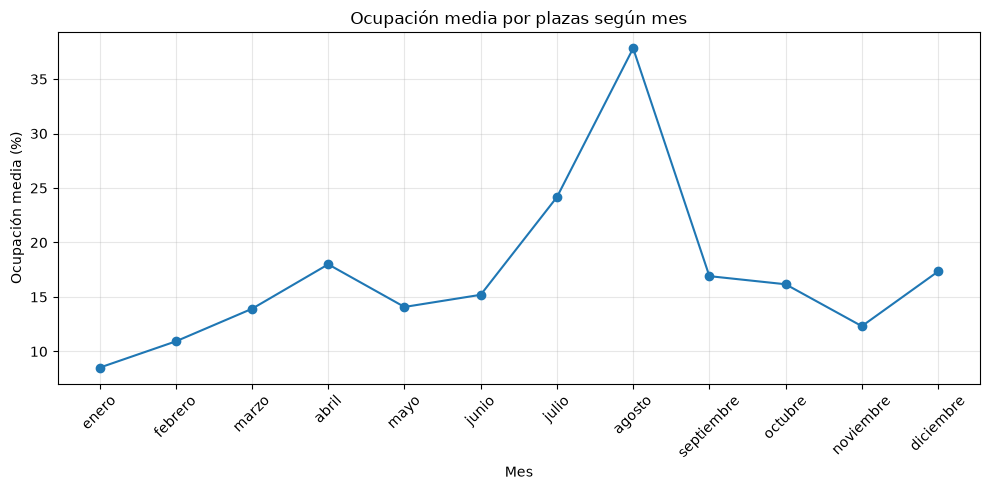

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    seasonal_monthly["month_name"],
    seasonal_monthly["mean_occupancy_rate"],
    marker="o",
)
ax.set_title("Ocupación media por plazas según mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupación media (%)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Provincias con mayor demanda reciente

Se utiliza el último año completo no provisional disponible: 2024.

In [16]:
ranking_2024 = (
    df[df["year"] == 2024]
    .groupby(
        ["territory_id", "territory_name", "autonomous_community_name"],
        as_index=False,
    )
    .agg(
        travellers_total=("travellers_total", "sum"),
        overnight_stays_total=("overnight_stays_total", "sum"),
        average_occupancy_rate=("occupancy_rate_pct", "mean"),
        average_pressure_index=("tourism_pressure_index", "mean"),
    )
    .sort_values("overnight_stays_total", ascending=False)
)

ranking_2024.head(15)

,territory_id,territory_name,autonomous_community_name,travellers_total,overnight_stays_total,average_occupancy_rate,average_pressure_index
6,ES-PROV-07,"Balears, Illes",Illes Balears,543974,1688709,49.21,67.65
32,ES-PROV-33,Asturias,Principado de Asturias,303870,929317,18.54,31.22
28,ES-PROV-29,Málaga,Andalucía,141791,754454,19.32,36.29
38,ES-PROV-39,Cantabria,Cantabria,269929,696366,22.30,40.80
16,ES-PROV-17,Girona,Cataluña,211735,568685,23.11,47.61
30,ES-PROV-31,Navarra,Comunidad Foral de Navarra,171878,441816,21.34,38.08
9,ES-PROV-10,Cáceres,Extremadura,177087,428422,15.63,31.81
7,ES-PROV-08,Barcelona,Cataluña,168222,415898,23.17,49.51
8,ES-PROV-09,Burgos,Castilla y León,156739,336236,20.08,46.37
21,ES-PROV-22,Huesca,Aragón,106370,325197,18.34,37.62


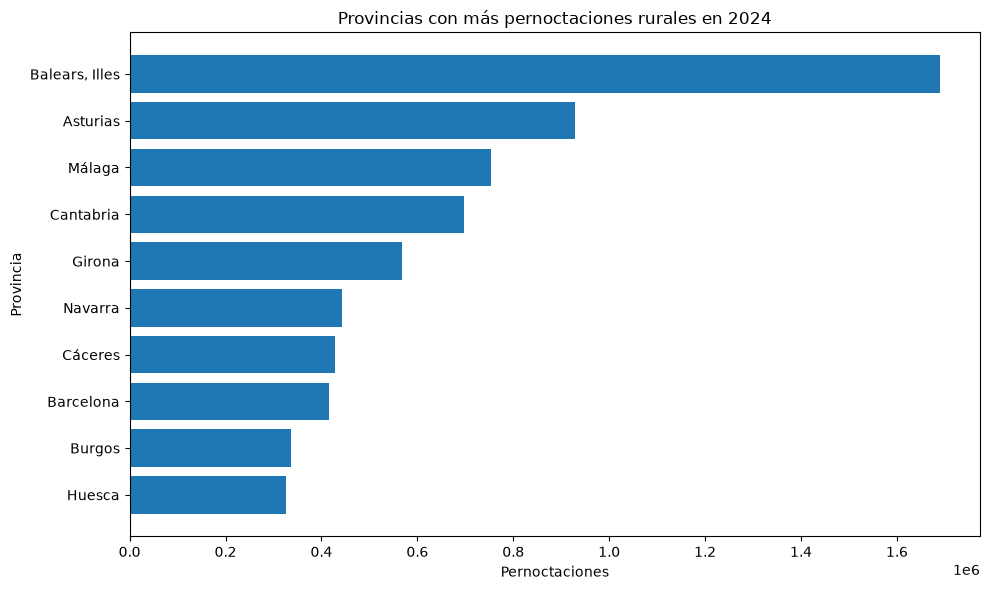

In [17]:
top_10 = ranking_2024.head(10).sort_values("overnight_stays_total")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_10["territory_name"], top_10["overnight_stays_total"])
ax.set_title("Provincias con más pernoctaciones rurales en 2024")
ax.set_xlabel("Pernoctaciones")
ax.set_ylabel("Provincia")
plt.tight_layout()
plt.show()

## 10. Demanda nacional y extranjera

In [18]:
origin_summary = pd.Series(
    {
        "viajeros_residentes_españa": df["travellers_domestic"].sum(),
        "viajeros_extranjeros": df["travellers_foreign"].sum(),
        "pernoctaciones_residentes_españa": df["overnight_stays_domestic"].sum(),
        "pernoctaciones_extranjeros": df["overnight_stays_foreign"].sum(),
    }
)

origin_summary

viajeros_residentes_españa           58809882
viajeros_extranjeros                 12209421
pernoctaciones_residentes_españa    151086756
pernoctaciones_extranjeros           46785442
dtype: int64

In [19]:
recent_origin = (
    df[df["year"] == 2024]
    .groupby("autonomous_community_name", as_index=False)
    .agg(
        travellers_domestic=("travellers_domestic", "sum"),
        travellers_foreign=("travellers_foreign", "sum"),
    )
)

recent_origin["foreign_share"] = (
    recent_origin["travellers_foreign"]
    / (recent_origin["travellers_domestic"] + recent_origin["travellers_foreign"])
)

recent_origin.sort_values("foreign_share", ascending=False).head(10)

,autonomous_community_name,travellers_domestic,travellers_foreign,foreign_share
12,Illes Balears,90936,453038,0.83
2,Canarias,36288,54911,0.60
11,Galicia,129080,76292,0.37
0,Andalucía,267942,137753,0.34
14,País Vasco,128135,51729,0.29
13,La Rioja,26091,8635,0.25
7,Comunidad Foral de Navarra,135501,36377,0.21
3,Cantabria,217189,52740,0.20
6,Cataluña,429146,83336,0.16
15,Principado de Asturias,255965,47905,0.16


## 11. Relación entre ocupación y presión turística

In [20]:
pressure_sample = df[
    ["territory_name", "month_id", "occupancy_rate_pct", "tourism_pressure_index"]
].dropna()

pressure_sample[["occupancy_rate_pct", "tourism_pressure_index"]].corr()

,occupancy_rate_pct,tourism_pressure_index
occupancy_rate_pct,1.00,0.73
tourism_pressure_index,0.73,1.00


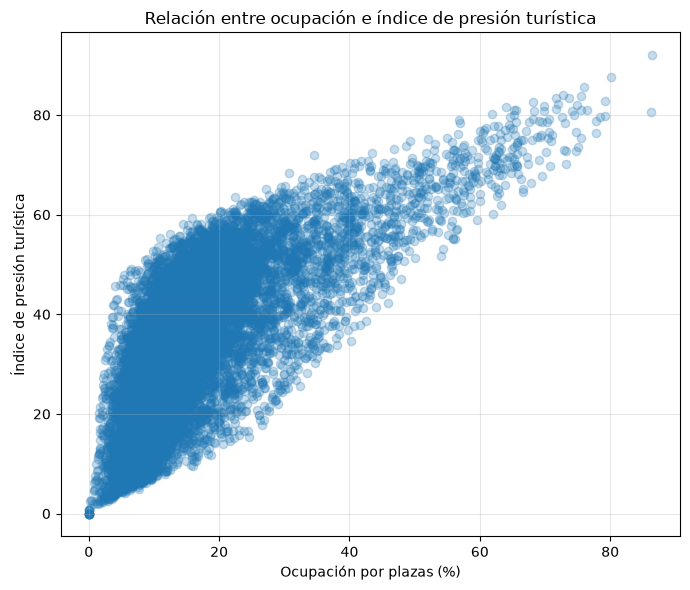

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    pressure_sample["occupancy_rate_pct"],
    pressure_sample["tourism_pressure_index"],
    alpha=0.25,
)
ax.set_title("Relación entre ocupación e índice de presión turística")
ax.set_xlabel("Ocupación por plazas (%)")
ax.set_ylabel("Índice de presión turística")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El índice de presión turística incorpora la ocupación, pero también las pernoctaciones por plaza, la tendencia interanual y la ocupación de fin de semana. Por eso no debe esperarse una correlación perfecta.

## 12. Caso de estudio: Santa Cruz de Tenerife

In [22]:
tenerife = (
    df[df["source_territory_code"] == "38"]
    .sort_values("date_month")
    .copy()
)

tenerife[
    [
        "territory_name",
        "month_id",
        "travellers_total",
        "overnight_stays_total",
        "average_stay",
        "occupancy_rate_pct",
        "tourism_pressure_index",
    ]
].tail(24)

,territory_name,month_id,travellers_total,overnight_stays_total,average_stay,occupancy_rate_pct,tourism_pressure_index
9621,Santa Cruz de Tenerife,2024-06,3124,14440,4.62,23.28,38.73
9622,Santa Cruz de Tenerife,2024-07,3431,18748,5.46,29.68,39.39
9623,Santa Cruz de Tenerife,2024-08,4996,24246,4.85,38.57,40.75
9624,Santa Cruz de Tenerife,2024-09,4516,19656,4.35,27.96,46.30
9625,Santa Cruz de Tenerife,2024-10,5167,23905,4.63,31.54,58.21
9626,Santa Cruz de Tenerife,2024-11,6414,31994,4.99,44.12,60.26
9627,Santa Cruz de Tenerife,2024-12,4686,28690,6.12,38.62,58.36
9628,Santa Cruz de Tenerife,2025-01,5478,30366,5.54,42.38,59.79
9629,Santa Cruz de Tenerife,2025-02,5561,29170,5.25,45.34,61.33
9630,Santa Cruz de Tenerife,2025-03,5734,30295,5.28,38.12,67.71


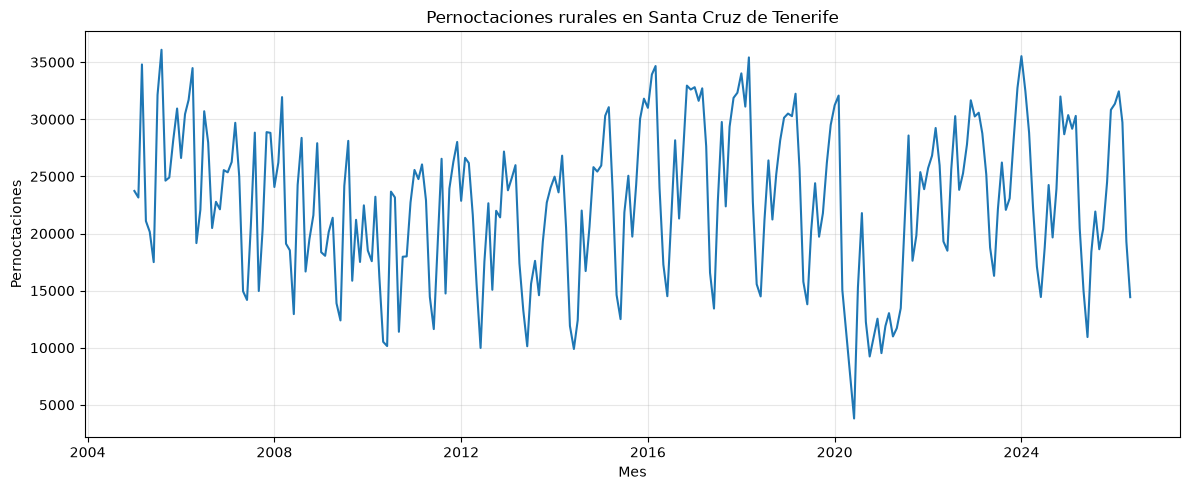

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tenerife["date_month"], tenerife["overnight_stays_total"])
ax.set_title("Pernoctaciones rurales en Santa Cruz de Tenerife")
ax.set_xlabel("Mes")
ax.set_ylabel("Pernoctaciones")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

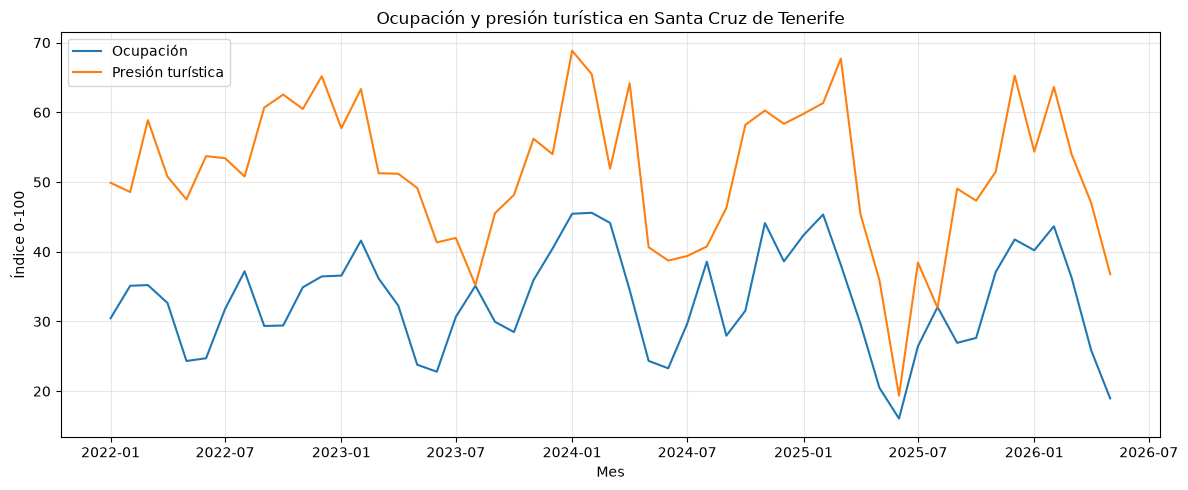

In [24]:
tenerife_recent = tenerife[tenerife["date_month"] >= "2022-01-01"]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tenerife_recent["date_month"], tenerife_recent["occupancy_rate_pct"], label="Ocupación")
ax.plot(tenerife_recent["date_month"], tenerife_recent["tourism_pressure_index"], label="Presión turística")
ax.set_title("Ocupación y presión turística en Santa Cruz de Tenerife")
ax.set_xlabel("Mes")
ax.set_ylabel("Índice 0-100")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
tenerife_seasonality = (
    tenerife[
        ~tenerife["covid_period"].fillna(False)
        & ~tenerife["is_provisional"].fillna(False)
    ]
    .groupby(["month", "month_name"], as_index=False)
    .agg(
        mean_overnight_stays=("overnight_stays_total", "mean"),
        mean_average_stay=("average_stay", "mean"),
        mean_pressure_index=("tourism_pressure_index", "mean"),
    )
    .sort_values("month")
)

tenerife_seasonality

,month,month_name,mean_overnight_stays,mean_average_stay,mean_pressure_index
0,1,enero,"27,060.00",6.84,54.94
1,2,febrero,"27,494.85",6.28,56.32
2,3,marzo,"29,458.79",6.37,56.03
3,4,abril,"23,006.32",6.25,49.48
4,5,mayo,"15,911.21",5.87,42.56
5,6,junio,"13,825.50",5.78,37.92
6,7,julio,"21,890.28",6.75,40.42
7,8,agosto,"26,436.50",6.74,34.99
8,9,septiembre,"18,614.33",5.85,43.64
9,10,octubre,"22,893.00",5.91,49.64


## 13. Crecimiento interanual reciente por provincia

In [26]:
latest_month = df["date_month"].max()

latest_snapshot = (
    df[df["date_month"] == latest_month][
        [
            "territory_name",
            "autonomous_community_name",
            "overnight_stays_total",
            "overnight_stays_yoy_change_pct",
            "occupancy_rate_pct",
            "tourism_pressure_index",
            "is_provisional",
        ]
    ]
    .sort_values("overnight_stays_yoy_change_pct", ascending=False)
)

print(f"Último mes disponible: {latest_month:%Y-%m}")
latest_snapshot.head(15)

Último mes disponible: 2026-05


,territory_name,autonomous_community_name,overnight_stays_total,overnight_stays_yoy_change_pct,occupancy_rate_pct,tourism_pressure_index,is_provisional
1015,Almería,Andalucía,6473,74.71,15.18,37.62,True
9136,Pontevedra,Galicia,9065,60.61,19.23,51.20,True
5326,Huelva,Andalucía,8138,54.42,18.12,45.33,True
5834,Jaén,Andalucía,7553,53.80,12.14,28.11,True
11168,Teruel,Aragón,17412,42.87,18.57,48.24,True
11676,Valencia/València,Comunitat Valenciana,13799,35.39,18.78,48.35,True
8120,Ourense,Galicia,4744,34.39,20.68,51.68,True
2786,Cádiz,Andalucía,10879,28.93,26.39,59.78,True
6342,Lleida,Cataluña,17751,28.34,14.60,33.85,True
12438,Zamora,Castilla y León,12753,23.60,16.59,37.29,True


Los datos del último mes son provisionales. Esta clasificación debe mantenerse visible en cualquier dashboard o análisis.

## 14. Resumen automático de hallazgos

In [27]:
best_2024 = ranking_2024.iloc[0]
highest_season = seasonal_monthly.loc[seasonal_monthly["mean_overnight_stays"].idxmax()]
tenerife_peak = tenerife.loc[tenerife["overnight_stays_total"].idxmax()]

findings = {
    "provincia_líder_2024": best_2024["territory_name"],
    "pernoctaciones_provincia_líder_2024": int(best_2024["overnight_stays_total"]),
    "mes_con_mayor_demanda_media": highest_season["month_name"],
    "máximo_histórico_tenerife_mes": tenerife_peak["month_id"],
    "máximo_histórico_tenerife_pernoctaciones": int(tenerife_peak["overnight_stays_total"]),
    "último_mes_disponible": latest_month.strftime("%Y-%m"),
    "último_mes_es_provisional": bool(latest_snapshot["is_provisional"].all()),
}

pd.Series(findings)

provincia_líder_2024                        Balears, Illes
pernoctaciones_provincia_líder_2024                1688709
mes_con_mayor_demanda_media                         agosto
máximo_histórico_tenerife_mes                      2005-08
máximo_histórico_tenerife_pernoctaciones             36085
último_mes_disponible                              2026-05
último_mes_es_provisional                             True
dtype: object

## 15. Conclusiones

El análisis exploratorio confirma que la tabla gold permite estudiar de forma consistente la evolución temporal, la estacionalidad y las diferencias territoriales de la demanda de turismo rural en España.

En 2024, **Illes Balears fue la provincia con mayor número de pernoctaciones rurales**, con un total de **1.688.709 pernoctaciones**. Este resultado muestra que la intensidad de la demanda rural presenta diferencias importantes entre territorios y que no puede interpretarse únicamente a partir del tamaño o la población de cada provincia.

El análisis estacional identifica **agosto como el mes con mayor demanda media**. Esta concentración implica que la planificación de las microempresas vinculadas al turismo rural debe considerar una fuerte variación a lo largo del año. La estacionalidad puede afectar a la necesidad de personal, el aprovisionamiento, la disponibilidad de servicios, las campañas de promoción y la coordinación con otras actividades económicas locales.

En el caso específico de **Santa Cruz de Tenerife**, el máximo histórico registrado en la serie analizada se produjo en **agosto de 2005**, con **36.085 pernoctaciones**. Los datos recientes muestran también oscilaciones mensuales relevantes en viajeros, pernoctaciones, estancia media, ocupación e índice de presión turística. Esto refuerza la utilidad de realizar análisis territoriales específicos, ya que el patrón de Tenerife no tiene por qué coincidir con el comportamiento medio del conjunto de España.

El último periodo disponible es **mayo de 2026**. Este dato, junto con todos los registros publicados desde junio de 2025, está marcado como **provisional**, por lo que podría ser revisado posteriormente por el INE. Esta condición deberá mostrarse claramente en los futuros modelos, visualizaciones y herramientas de apoyo a la decisión.

Los resultados también muestran que la demanda turística rural está marcada por:

* una estacionalidad mensual elevada;
* diferencias sustanciales entre provincias;
* perfiles distintos de demanda residente y extranjera;
* cambios significativos durante el periodo de la COVID-19;
* relaciones entre demanda, capacidad disponible, ocupación e intensidad turística;
* valores ausentes derivados de información no publicada en la fuente original.

Los meses de abril de 2020, mayo de 2020 y noviembre de 2020 no aparecen en la tabla gold porque no contienen observaciones provinciales de demanda publicadas. Estos periodos no se han rellenado artificialmente con ceros, ya que la ausencia de información no equivale a una demanda inexistente.

Desde el punto de vista del producto, la capa gold ofrece una base útil para desarrollar un sistema de apoyo dirigido a pequeñas empresas y microempresas rurales. Permite identificar temporadas de mayor actividad, comparar territorios, analizar la evolución de la demanda y detectar contextos de mayor presión turística. Estas señales podrían utilizarse posteriormente para orientar decisiones relacionadas con horarios, contratación, inventario, promoción, colaboración entre empresas y adaptación de servicios.

No obstante, los indicadores deben interpretarse como **señales territoriales agregadas**. No representan directamente la facturación, la rentabilidad o la demanda de una empresa concreta. En las siguientes fases será necesario mantener esta distinción, evaluar la capacidad predictiva de las variables y documentar las limitaciones de cualquier recomendación generada.

En conjunto, el análisis confirma que el modelo de datos construido es coherente, trazable y suficientemente sólido para avanzar hacia la preparación del dataset de modelado predictivo y la evaluación de modelos de referencia.